# <font color="blue">**WORD2VEC VARIANT USING NUMPY**</font>
## Author: Virginia Antón Yuste

**Task Description**: Implement the core training loop of word2vec in pure NumPy (no PyTorch / TensorFlow or other ML frameworks). The applicant is free to choose any suitable text dataset. The task is to implement the optimization procedure (forward pass, loss, gradients, and parameter updates) for a standard word2vec variant (e.g. skip-gram with negative sampling or CBOW).


This notebook aims to implement the training stage of a Skip-Gram model using NumPy. It loads the preprocessed dataset generated in the preprocessing step and uses it to train word embeddings.

In [232]:
import pickle
import numpy as np
import pandas as pd
import re
import pickle # to save and load the model
import os # to join the path
import random # for randomly generated numbers
import time # to record time for the report
import matplotlib.pyplot as plt # to plot the loss of experiments for the report

In [234]:

pairs = pickle.load(open("pairs.pkl", "rb"))
indexed_corpus = pickle.load(open("corpus.pkl", "rb"))
id2word= pickle.load(open("id2word.pkl", "rb"))
word2id = pickle.load(open("word2id.pkl", "rb"))

In [236]:
#We denote our vocabulary size (unique words), 
#useful to calculate the dimension of word vectors
vocab_size = len(word2id)
vocab_size

1497

In [238]:
pairs[:10]

[(695, 358),
 (695, 305),
 (358, 695),
 (358, 305),
 (358, 1260),
 (305, 695),
 (305, 358),
 (305, 1260),
 (305, 741),
 (1260, 358)]

## 2. BATCH GENERATION
Batch generation will make the training faster. 

In [241]:
def batchGeneration(pairs, batch_size):
    for i in range(0, len(pairs), batch_size):
        batch = pairs[i:i+batch_size]
        targets = np.array([p[0] for p in batch])
        contexts = np.array([p[1] for p in batch])
        yield targets, contexts

## 3. SKIP-GRAM MODEL

Unlike Word2Vec, we want to answer the question : *"does these two words :"bed, story" appear together?"* And answer with *Yes/No*
This implies we need to learn the weights of the hidden layer and the output layer, which will be denoted as W_1 (center-word embeddings, input of the model) and W_2 (context word embeddings, output of the model). 

The probability vector will be calculated using sigmoid function instead of softmax. The aim is not to update all tokens' embeddings but only update a samll set of weights associated with a target (center word), context words and noise words. That said, we want to turn it to a binary classification problem, updating just the target, the true context of the word and k randomly drawn noise words. 

Creation of the model of two layers

In [358]:
class skipGramModel:
    """
    Model Parameters: 
        - vocab_size: number of unque words
        - embedding_dim: dimensionality of word vectors, is the 4th root of vocab_size
        - k: number of negative samples per positive pair (p)
        - learning_rate
        """
    
    def __init__(self, vocab_size, embedding_dim=32, k=5, learning_rate=0.025):

        self.vocab_size=vocab_size
        self.embedding_dim=embedding_dim
        self.k=k
        self.lr= learning_rate
        
        #weight initialisation, with uniform distribution 
        
        self.W1= np.random.uniform(-0.5,0.5,(vocab_size, embedding_dim))/vocab_size
        self.W2 = np.zeros((vocab_size, embedding_dim))

    @staticmethod 
    def sigmoid(x):
        """Return logarithmic value of the sigmoid of x (int)"""
        return 1.0/(1 + np.exp(-x))

    def generateNegativeSamples(self, target):
        """
        Sampling of k words that are not the target
         - target: word ID of te center (target) word
         - k: how many negative samples to draw
         - vocab_size: vocabulary size
         Returns negativeSamples (array): of shape k with words indexes
         """
    
        negativeSamples=[]
        while len(negativeSamples) <= self.k:
            candidate = np.random.randint(0, self.vocab_size)
            if candidate != target:
                negativeSamples.append(candidate)
        return np.array(negativeSamples)

    def forwardprop(self, target, context, negativeSamples):
        """
        Compute dot product for positive and negative pairs. All in all, returns how similar the pairs are with the target 
            - target: ID of center-word
            - context: ID of contexts words
            - negativeSamples: array of shape k with word indexes
            Returns:
            - t: array shape of embeding_dim, is target embedding vector
            - sigPos: float, sigmoid's result (probability) of dot product target · t
            - sigNeg: array of shape (k,1), sigmoid's result (probability)  of dot product context_vector · t
            """
        t = self.W1[target] 
        sigPos=self.sigmoid(np.dot(self.W2[context], t))
        sigNeg= self.sigmoid(np.dot(self.W2[negativeSamples],t))
        
        return t, sigPos, sigNeg

    def loss(self, sigPos, sigNeg):
        """
        Negative Sampling Loss (L)
            - sigPos: float, sigmoid score of positive pair. 
            - sigNeg: array of shape k, sigmoid scores od negative pairs
            """
        err=1e-10 #avoid log(0)
        L = -(np.log(sigPos) + np.sum(np.log(1.0-sigNeg+err)))
        return L
        
    def backwardprop(self, target, context, negativeSamples, t, sigPos, sigNeg):
        """
        Compute gradients and update W1 and W2 in-place.
            - target, context, negativeSamples: same as in fowardprop()
            - t: center-word embedding array from forwardprop()
            - sigPos: float, positive sigmoid score from forwardprop()
            - sigNeg: array, negative sigmoid score from forwardprop of shape (5,)
            """
        
        #W2[context] & W2[negativeSamples] gradients
        delta_pos = sigPos - 1.0
        delta_neg = sigNeg

        #Gradient of W1[target], shape(embeding_dim, )
        gradt = (delta_pos * self.W2[context] + np.dot(delta_neg, self.W2[negativeSamples]))

        #Embeddings updates
        self.W2[context] -= self.lr * delta_pos * t
        self.W2[negativeSamples] -= self.lr * delta_neg[:, np.newaxis] * t
        self.W1[target] -= self.lr * gradt

    def step(self, target, context):
        """
        Update of a single (target, context) pair. 
        Returns loss for this pair
        
        """
        negativeSamples = self.generateNegativeSamples(target)
        t, sigPos, sigNeg = self.forwardprop(target, context, negativeSamples)
        currentLoss= self.loss(sigPos, sigNeg)
        self.backwardprop(target, context, negativeSamples, t, sigPos, sigNeg)
        
        return currentLoss

    def save(self, path):
        """
        Save model in pickle file
        """
        with open(path, 'wb') as f:
            pickle.dump(self, f)
        print(f"Model saved to {path}")
        
    @staticmethod
    def load(path):
        """Load model from pickle file"""
        with open(path, 'rb') as f:
            return picke.load(f)
            
    def __repr__(self):
        return(f"SkipGramModel(vocab_size={self.vocab_size},"
              f"embedding_dim={self.embedding_dim},"
                f"k={self.k},"
                f"learning_rate={self.lr})")
        
        

## 4. TRAINING LOOP

In [361]:
def train(model, pairs, epochs=5, batch_size=512):
    """
    Train SkipGramModel over multiple epochs
        - model: skipGramModel
        - pairs: (list of target_id, context_id) tuples
        - epochs: int, number of full passes over the data
        - batch_size: int, pairs per batch
    Returns epoch_losses: list of floats, with the average loss per epoch
    """
    epoch_losses = []
    for epoch in range(1, epochs+1):
        random.shuffle(pairs)
        totalLoss = 0.0
        numPairs = 0
        t0 = time.time()

        for targets,contexts in batchGeneration(pairs, batch_size):
            for target, context in zip(targets, contexts):
                totalLoss += model.step(target, context)
                numPairs += 1
        avgLoss = totalLoss / max(numPairs, 1)
        epoch_losses.append(avgLoss)
        print(f"Epoch {epoch}/{epochs}  |  "
              f"loss: {avgLoss:.4f}  |  "
              f"pairs: {numPairs:,}  |  "
              f"time: {time.time() - t0:.1f}s")
    return epoch_losses


## 5. RUN 

In [364]:
model = skipGramModel(vocab_size, 32, 5, 0.025)
print(model)
epoch_losses = train(model, pairs, epochs = 20, batch_size = 512)

SkipGramModel(vocab_size=1497,embedding_dim=32,k=5,learning_rate=0.025)
Epoch 1/20  |  loss: 4.8520  |  pairs: 38,798  |  time: 3.8s
Epoch 2/20  |  loss: 4.6393  |  pairs: 38,798  |  time: 3.6s
Epoch 3/20  |  loss: 2.9755  |  pairs: 38,798  |  time: 3.7s
Epoch 4/20  |  loss: 2.3577  |  pairs: 38,798  |  time: 3.8s
Epoch 5/20  |  loss: 2.1986  |  pairs: 38,798  |  time: 3.6s
Epoch 6/20  |  loss: 2.1288  |  pairs: 38,798  |  time: 3.8s
Epoch 7/20  |  loss: 2.0974  |  pairs: 38,798  |  time: 3.7s
Epoch 8/20  |  loss: 2.0745  |  pairs: 38,798  |  time: 3.6s
Epoch 9/20  |  loss: 2.0482  |  pairs: 38,798  |  time: 3.0s
Epoch 10/20  |  loss: 2.0267  |  pairs: 38,798  |  time: 3.5s
Epoch 11/20  |  loss: 2.0048  |  pairs: 38,798  |  time: 3.7s
Epoch 12/20  |  loss: 1.9818  |  pairs: 38,798  |  time: 3.6s
Epoch 13/20  |  loss: 1.9640  |  pairs: 38,798  |  time: 3.7s
Epoch 14/20  |  loss: 1.9320  |  pairs: 38,798  |  time: 3.6s
Epoch 15/20  |  loss: 1.9215  |  pairs: 38,798  |  time: 3.7s
Epoch 1

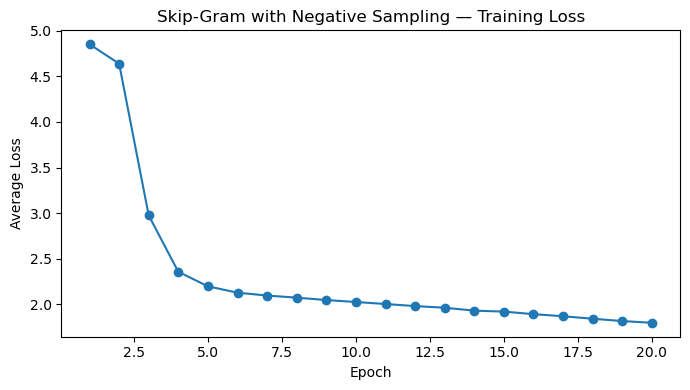

In [366]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Skip-Gram with Negative Sampling — Training Loss')
plt.tight_layout()
plt.show()

In [368]:
model.save('skipgram_model.pkl')

Model saved to skipgram_model.pkl


## 6. MODEL EVALUATION

In this part of the project, we are going to find out i the pair of embeddings make sense. 
If the model has learnt correctly, we should see similar context word vectors, when words are semantically related. 

For this task, I will use the function cosine similarity, as it measures the angle, and at embeddings what we want to know is vector direction in space. 
We are going to obtain results between -1 and 1, the closer to one the similar the vectors are. 

In [372]:
def near_neighbours(word, word2id, id2word, model, topK=10):
    if word not in word2id:
        print(f"{word} not in vocabulary")
        return
        
    wordId = word2id[word]
    vector = model.W1[wordId]
    norms = np.linalg.norm(model.W1, axis=1) + 1e-10
    sims = np.dot(model.W1, vector) / (norms * np.linalg.norm(vector))
    sims[wordId] = -1 #avoid the word itself
    
    topids = np.argsort(sims)[::1][:topK]
    print(f"Nearest neighbors of: {word}")
    for rank, idx in enumerate(topids, 1):
        print(f"{rank:2d}. {id2word[idx]:20s} sim={sims[idx]:.4f}")

In [419]:
near_neighbours('sister', word2id, id2word, model)

Nearest neighbors of: sister
 1. sister               sim=-1.0000
 2. stars                sim=0.3987
 3. one                  sim=0.4422
 4. would                sim=0.4424
 5. night                sim=0.4583
 6. magical              sim=0.4630
 7. window               sim=0.4686
 8. sky                  sim=0.4707
 9. star                 sim=0.4751
10. make                 sim=0.4793


## 7. EXPERIMENTS

This section aims to find the best configuration for the model, because is not yet very accurate. 

#### a) Experiments with learning rate

In [379]:
learning_rate = [0.025, 0.01, 0.05, 0.1]

#Static hyperparameters
EPOCHS = 20
BATCH_SIZE = 512

results = {} #store losses en  each epoch

Epoch 1/20  |  loss: 4.8520  |  pairs: 38,798  |  time: 3.6s
Epoch 2/20  |  loss: 4.6286  |  pairs: 38,798  |  time: 3.8s
Epoch 3/20  |  loss: 2.9615  |  pairs: 38,798  |  time: 3.8s
Epoch 4/20  |  loss: 2.3598  |  pairs: 38,798  |  time: 3.7s
Epoch 5/20  |  loss: 2.1999  |  pairs: 38,798  |  time: 3.9s
Epoch 6/20  |  loss: 2.1345  |  pairs: 38,798  |  time: 3.7s
Epoch 7/20  |  loss: 2.1008  |  pairs: 38,798  |  time: 2.4s
Epoch 8/20  |  loss: 2.0760  |  pairs: 38,798  |  time: 3.9s
Epoch 9/20  |  loss: 2.0526  |  pairs: 38,798  |  time: 3.4s
Epoch 10/20  |  loss: 2.0300  |  pairs: 38,798  |  time: 3.6s
Epoch 11/20  |  loss: 2.0121  |  pairs: 38,798  |  time: 3.5s
Epoch 12/20  |  loss: 1.9932  |  pairs: 38,798  |  time: 3.5s
Epoch 13/20  |  loss: 1.9734  |  pairs: 38,798  |  time: 3.3s
Epoch 14/20  |  loss: 1.9460  |  pairs: 38,798  |  time: 3.6s
Epoch 15/20  |  loss: 1.9230  |  pairs: 38,798  |  time: 3.1s
Epoch 16/20  |  loss: 1.8966  |  pairs: 38,798  |  time: 2.8s
Epoch 17/20  |  l

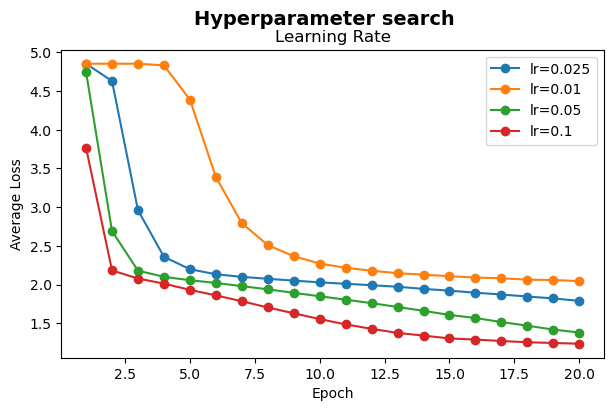

In [381]:
fig, ax = plt.subplots(figsize=(7,4))
fig.suptitle("Hyperparameter search", fontsize=14, fontweight='bold')

for lr in learning_rate:
    model_exp1 = skipGramModel(vocab_size, 32, 5, lr)
    losses = train(model_exp1, pairs, EPOCHS, BATCH_SIZE)
    ax.plot(range(1,EPOCHS+1), losses, marker='o', label=f"lr={lr}")
ax.set_title("Learning Rate")
ax.set_xlabel("Epoch")
ax.set_ylabel("Average Loss")
ax.legend()

We can see that the best learning rate, with the lowest average loss is lr = 0.1, is the one that converge the fastest too. However, we see that the curve hasn't converge completely, so it can be more optimized if we combine this configuration with the variation of other hyperparameters. 

What it surprised me is that the worst learning rate value is 0.01, it seems it learns very slow compared to the others. 

#### b) Embedding Dimension

In [384]:
embed_dim= [32, 50, 100, 200]
results = {} #store losses en  each epoch


Epoch 1/20  |  loss: 4.8520  |  pairs: 38,798  |  time: 3.5s
Epoch 2/20  |  loss: 4.5957  |  pairs: 38,798  |  time: 2.7s
Epoch 3/20  |  loss: 2.9245  |  pairs: 38,798  |  time: 1.7s
Epoch 4/20  |  loss: 2.3449  |  pairs: 38,798  |  time: 3.7s
Epoch 5/20  |  loss: 2.1929  |  pairs: 38,798  |  time: 3.9s
Epoch 6/20  |  loss: 2.1344  |  pairs: 38,798  |  time: 3.9s
Epoch 7/20  |  loss: 2.0925  |  pairs: 38,798  |  time: 3.6s
Epoch 8/20  |  loss: 2.0713  |  pairs: 38,798  |  time: 3.2s
Epoch 9/20  |  loss: 2.0436  |  pairs: 38,798  |  time: 3.6s
Epoch 10/20  |  loss: 2.0266  |  pairs: 38,798  |  time: 3.5s
Epoch 11/20  |  loss: 2.0101  |  pairs: 38,798  |  time: 3.6s
Epoch 12/20  |  loss: 1.9871  |  pairs: 38,798  |  time: 3.6s
Epoch 13/20  |  loss: 1.9642  |  pairs: 38,798  |  time: 3.6s
Epoch 14/20  |  loss: 1.9449  |  pairs: 38,798  |  time: 3.5s
Epoch 15/20  |  loss: 1.9212  |  pairs: 38,798  |  time: 3.5s
Epoch 16/20  |  loss: 1.8967  |  pairs: 38,798  |  time: 3.5s
Epoch 17/20  |  l

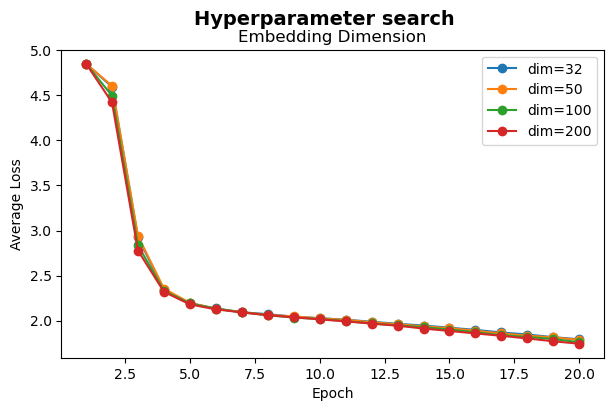

In [385]:
fig, ax = plt.subplots(figsize=(7, 4))
fig.suptitle("Hyperparameter search", fontsize=14, fontweight='bold')
for dim in embed_dim:
    model_exp2 = skipGramModel(vocab_size, dim, 5, 0.025)
    losses = train(model_exp2, pairs, EPOCHS, BATCH_SIZE)
    ax.plot(range(1,21), losses, marker='o', label=f"dim={dim}")
ax.set_title("Embedding Dimension")
ax.set_xlabel("Epoch")
ax.set_ylabel("Average Loss")
ax.legend()    

Not surprising at all, because the vocabulary size (1606 words) is not so big. Therefore, with 32 dimensions will be enough. 

### c) Number of Negative Samples

In [391]:
negSam= [2, 5, 7, 10]
results = {} #store losses en  each epoch

Epoch 1/20  |  loss: 2.7726  |  pairs: 38,798  |  time: 3.3s
Epoch 2/20  |  loss: 2.7713  |  pairs: 38,798  |  time: 3.3s
Epoch 3/20  |  loss: 2.6273  |  pairs: 38,798  |  time: 3.3s
Epoch 4/20  |  loss: 2.1263  |  pairs: 38,798  |  time: 3.2s
Epoch 5/20  |  loss: 1.8292  |  pairs: 38,798  |  time: 3.2s
Epoch 6/20  |  loss: 1.7166  |  pairs: 38,798  |  time: 2.8s
Epoch 7/20  |  loss: 1.6611  |  pairs: 38,798  |  time: 3.3s
Epoch 8/20  |  loss: 1.6281  |  pairs: 38,798  |  time: 3.3s
Epoch 9/20  |  loss: 1.6105  |  pairs: 38,798  |  time: 3.1s
Epoch 10/20  |  loss: 1.5867  |  pairs: 38,798  |  time: 3.1s
Epoch 11/20  |  loss: 1.5769  |  pairs: 38,798  |  time: 3.3s
Epoch 12/20  |  loss: 1.5626  |  pairs: 38,798  |  time: 3.2s
Epoch 13/20  |  loss: 1.5433  |  pairs: 38,798  |  time: 3.1s
Epoch 14/20  |  loss: 1.5315  |  pairs: 38,798  |  time: 3.0s
Epoch 15/20  |  loss: 1.5162  |  pairs: 38,798  |  time: 2.4s
Epoch 16/20  |  loss: 1.5034  |  pairs: 38,798  |  time: 3.3s
Epoch 17/20  |  l

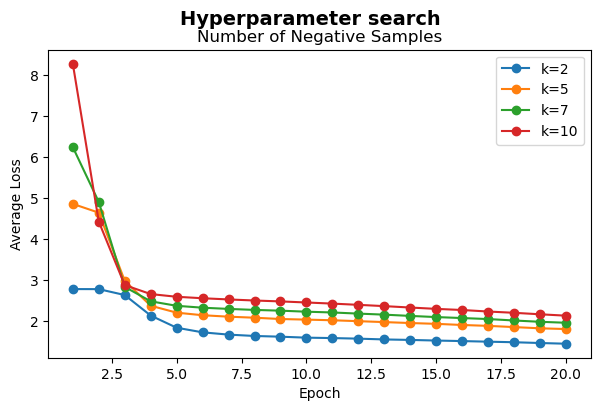

In [393]:
fig, ax = plt.subplots(figsize=(7, 4))
fig.suptitle("Hyperparameter search", fontsize=14, fontweight='bold')

for k in negSam:
    model_exp3 = skipGramModel(vocab_size, 32, k, 0.025)
    losses = train(model_exp3, pairs, EPOCHS, BATCH_SIZE)
    ax.plot(range(1,21), losses, marker='o', label=f"k={k}")
ax.set_title("Number of Negative Samples")
ax.set_xlabel("Epoch")
ax.set_ylabel("Average Loss")
ax.legend()    

Here there's a dilemma, because, from the one hand, k=2 seems to be the best option, although our dataset is too small for just k=2, because there are a few negative pairs, so the model could not distinguish between fake pairs and real pairs. 
k=5 has a higher average loss, but i think that compared to k=7 and k=10, is more optimmal in the learning and the velocity of the model.
Therefore, the best configuration is k=5. 

### BEST CONFIGURATION

With the above experiments I found out that the lower loss would be using *learning_rate =0.1, embedding_dim=32, k=5*. 

In [398]:
model2 = skipGramModel(vocab_size, 32, 5, 0.1)
print(model2)
epoch_losses = train(model2, pairs, epochs = 20, batch_size = 512)

SkipGramModel(vocab_size=1497,embedding_dim=32,k=5,learning_rate=0.1)
Epoch 1/20  |  loss: 3.7183  |  pairs: 38,798  |  time: 3.6s
Epoch 2/20  |  loss: 2.1781  |  pairs: 38,798  |  time: 3.6s
Epoch 3/20  |  loss: 2.0761  |  pairs: 38,798  |  time: 3.3s
Epoch 4/20  |  loss: 2.0125  |  pairs: 38,798  |  time: 3.7s
Epoch 5/20  |  loss: 1.9385  |  pairs: 38,798  |  time: 3.8s
Epoch 6/20  |  loss: 1.8651  |  pairs: 38,798  |  time: 3.6s
Epoch 7/20  |  loss: 1.7891  |  pairs: 38,798  |  time: 2.5s
Epoch 8/20  |  loss: 1.7097  |  pairs: 38,798  |  time: 3.8s
Epoch 9/20  |  loss: 1.6274  |  pairs: 38,798  |  time: 3.9s
Epoch 10/20  |  loss: 1.5491  |  pairs: 38,798  |  time: 3.8s
Epoch 11/20  |  loss: 1.4986  |  pairs: 38,798  |  time: 3.6s
Epoch 12/20  |  loss: 1.4299  |  pairs: 38,798  |  time: 3.5s
Epoch 13/20  |  loss: 1.3844  |  pairs: 38,798  |  time: 3.6s
Epoch 14/20  |  loss: 1.3420  |  pairs: 38,798  |  time: 3.5s
Epoch 15/20  |  loss: 1.3106  |  pairs: 38,798  |  time: 3.1s
Epoch 16/

In [421]:
#Evaluation of the new model
near_neighbours('sister', word2id, id2word, model2)

Nearest neighbors of: sister
 1. sister               sim=-1.0000
 2. eventually           sim=-0.1280
 3. learned              sim=-0.0505
 4. asked                sim=-0.0344
 5. way                  sim=-0.0329
 6. dragon               sim=-0.0317
 7. moonlight            sim=-0.0303
 8. heard                sim=-0.0150
 9. listening            sim=-0.0149
10. melody               sim=-0.0125


**Analysis**: Eventhough the average loss was smaller, the similarity vector is negative, so vectors have opposite direction to target word. This seems like the value of 0.1 makes the model to overshoot. 
Let's try with learnig_rate = 0.05

In [403]:
model3 = skipGramModel(vocab_size, 32, 5, 0.05)
print(model3)
epoch_losses = train(model3, pairs, epochs = 20, batch_size = 512)

SkipGramModel(vocab_size=1497,embedding_dim=32,k=5,learning_rate=0.05)
Epoch 1/20  |  loss: 4.7331  |  pairs: 38,798  |  time: 3.8s
Epoch 2/20  |  loss: 2.6779  |  pairs: 38,798  |  time: 3.6s
Epoch 3/20  |  loss: 2.1828  |  pairs: 38,798  |  time: 3.0s
Epoch 4/20  |  loss: 2.0965  |  pairs: 38,798  |  time: 3.6s
Epoch 5/20  |  loss: 2.0602  |  pairs: 38,798  |  time: 3.8s
Epoch 6/20  |  loss: 2.0271  |  pairs: 38,798  |  time: 3.9s
Epoch 7/20  |  loss: 1.9833  |  pairs: 38,798  |  time: 3.9s
Epoch 8/20  |  loss: 1.9379  |  pairs: 38,798  |  time: 3.8s
Epoch 9/20  |  loss: 1.8975  |  pairs: 38,798  |  time: 3.9s
Epoch 10/20  |  loss: 1.8410  |  pairs: 38,798  |  time: 3.9s
Epoch 11/20  |  loss: 1.8010  |  pairs: 38,798  |  time: 3.9s
Epoch 12/20  |  loss: 1.7472  |  pairs: 38,798  |  time: 3.8s
Epoch 13/20  |  loss: 1.7032  |  pairs: 38,798  |  time: 3.8s
Epoch 14/20  |  loss: 1.6604  |  pairs: 38,798  |  time: 3.7s
Epoch 15/20  |  loss: 1.6111  |  pairs: 38,798  |  time: 3.0s
Epoch 16

In [417]:
#Evaluation of the new model
near_neighbours('sister', word2id, id2word, model3)

Nearest neighbors of: sister
 1. sister               sim=-1.0000
 2. star                 sim=-0.0005
 3. special              sim=-0.0002
 4. suddenly             sim=0.0040
 5. mommy                sim=0.0092
 6. gentle               sim=0.0274
 7. heard                sim=0.0360
 8. gift                 sim=0.0413
 9. whisper              sim=0.0418
10. make                 sim=0.0522


**Analysis**: it keeps getting a negative similarity, so the best learning rate value is 0.025. 

## CONCLUSION

The notebook implements a Skip-gram Model with Negative Sampling from scratch using Numpy, it's trained on a dataset of bedtime stories, with a vocabulary of 1,497 unique words and 38,798 pairs. 

##### Hyperparameter search

Three hyperparameter were evaluated:
 - **Learning Rate**: values of 0.025, 0.01, 0.05, 0.1 were tested. Although lr = 0.1 achived the lowest average loss, when evaluating via nearest neighbors cosine similarities, indicates the model overshot during the training. Lr = 0.025 produced semantically coherent neighbors despite a higher loss. So it demostrates that the loss is not only the main evaluation metric.

 - **Embedding dimension**: dimensions of 32,50,100,200 were tested, they showed almost identical curves. It is something coherent as the vocabulary size is small. So 32 are enough dimensions to distinguish 1,497 words.

 - **Negative samples**: values of 2,5,7, 10 were tested. k= 2 appears to have the lowest loss but for a small dataset, k=5 has an optimal balances between learning and training speed.

 - Best configuration, seems to be learning rate = 0.025 with positive cosine similarities. Embedding dimension= 32, and k = 5. And in training epochs = 20, as loss converges around epoch 20.


##### Qualitative evaluation

While nearest neighbors displayed for are stars, one, would, night, magical, window... could be acceptable coming from ur dataset, I would have expected in the list words like "mother", "girl", "brother", that are in the dataset and semantically more similar. This demostrates that the model can be improved for the task asked. 

Some improvements could be:
- Noise distribution: to overcome the problem of all words having the same probability to be selected as negative. 
- Use a bigger dataset